In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy
import torchvision

train = torchvision.datasets.MNIST('mnist', train = True, download = True)
test = torchvision.datasets.MNIST('mnist', train = False, download = True)

train_images = numpy.array([ numpy.array(item[0]) / 255 for item in train ])
train_labels = numpy.array([ item[1] for item in train ])

test_images = numpy.array([ numpy.array(item[0]) / 255 for item in test ])
test_labels = numpy.array([ item[1] for item in test ])

In [3]:
train = torchvision.datasets.CIFAR10('cifar-10', train = True, download = True)
test = torchvision.datasets.CIFAR10('cifar-10', train = False, download = False)

train_images = numpy.array([ numpy.array(item[0]) / 255 for item in train ])
train_labels = numpy.array([ item[1] for item in train ])

test_images = numpy.array([ numpy.array(item[0]) / 255 for item in test ])
test_labels = numpy.array([ item[1] for item in test ])

Files already downloaded and verified


In [ ]:
import numpy
import torchvision
import torchvision.transforms.v2

transform = torchvision.transforms.v2.Compose([
    torchvision.transforms.v2.Resize((64, 64), antialias = True)
])

train = torchvision.datasets.Imagenette('imagenette', split = 'train', size = '160px', transform = transform, download = False)
test = torchvision.datasets.Imagenette('imagenette', split = 'val', size = '160px', transform = transform, download = False)

train_images = numpy.array([ numpy.array(item[0]) / 255 for item in train ])
train_labels = numpy.array([ item[1] for item in train ])

test_images = numpy.array([ numpy.array(item[0]) / 255 for item in test ])
test_labels = numpy.array([ item[1] for item in test ])

print(train_images.shape, test_images.shape)

(9469, 28, 28, 3) (3925, 28, 28, 3)


In [17]:
import cvtda.utils
from sklearn.model_selection import train_test_split

FRACTION = 0.25

idxs, _ = train_test_split(numpy.arange(len(train_labels)), stratify=train_labels, train_size = FRACTION, random_state = 42)
train_images = cvtda.utils.rgb2gray(train_images[idxs])
train_labels = train_labels[idxs]

idxs, _ = train_test_split(numpy.arange(len(test_labels)), stratify=test_labels, train_size = FRACTION, random_state = 42)
test_images = cvtda.utils.rgb2gray(test_images[idxs])
test_labels = test_labels[idxs]

train_images.shape, test_images.shape

rgb2gray: 100%|██████████| 981/981 [00:00<00:00, 12142.84it/s]


((2367, 28, 28), (981, 28, 28))

In [18]:
import cvtda.topology
extractor = cvtda.topology.FeatureExtractor(
    only_get_from_dump = False,
    return_diagrams = False,
    reduced = True,
    with_inverted = False,
    num_radial_filtrations = 2,
    binarizer_thresholds = [0.5],
    height_filtration_directions = [(-1, -1), (1, -1), (-1, 1), (1, 1)]
)
train_features = extractor.fit_transform(train_images, "train")
test_features = extractor.transform(test_images, "test")

train_features.shape, test_features.shape

Calculating inverted images
GreyscaleExtractor: processing train/greyscale, do_fit = True
Saving the result to ./train/greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
DiagramVectorizer: fitting complete


DiagramVectorizer: batch: 100%|██████████| 16/16 [00:08<00:00,  1.99it/s]


Saving the result to ./train/greyscale/features.npy
GreyscaleExtractor: processing train/greyscale, do_fit = False
Got the result from ./train/greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
Got the result from ./train/greyscale/features.npy
Fitting filtrations


100%|██████████| 8/8 [00:32<00:00,  4.12s/it]


Applying filtrations


...

DiagramVectorizer: batch: 100%|██████████| 16/16 [00:05<00:00,  2.84it/s]


Saving the result to ./test/greyscale/features.npy
Applying filtrations


GrayGeometryExtractor: 100%|██████████| 981/981 [00:12<00:00, 78.88it/s] 


Saving the result to ./test/geometry/features.npy
Applying StandardScaler.


((2367, 3625), (981, 3625))

In [19]:
import cvtda.topology
extractor = cvtda.topology.FeatureExtractor(
    only_get_from_dump = True,
    return_diagrams = True,
    reduced = True,
    with_inverted = False,
    num_radial_filtrations = 2,
    binarizer_thresholds = [0.5],
    height_filtration_directions = [(-1, -1), (1, -1), (-1, 1), (1, 1)]
)
extractor = extractor.fit(train_images, "train")
train_diagrams = extractor.transform(train_images, "train")
test_diagrams = extractor.transform(test_images, "test")

Calculating inverted images
Got the result from ./train/greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
Got the result from ./train/greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
Fitting filtrations


100%|██████████| 8/8 [00:03<00:00,  2.15it/s]


Applying filtrations


100%|██████████| 8/8 [00:00<00:00, 46.06it/s]


Diagrams requested. Returning diagrams.
Calculating inverted images
Got the result from ./train/greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
Applying filtrations


100%|██████████| 8/8 [00:00<00:00, 46.98it/s]


Diagrams requested. Returning diagrams.
Calculating inverted images
Got the result from ./test/greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
Applying filtrations


100%|██████████| 8/8 [00:00<00:00, 47.33it/s]

Diagrams requested. Returning diagrams.


Dataset: processing diagrams: 100%|██████████| 9/9 [00:00<00:00, 15.55it/s]


Constructed a dataset of 2367 images of shape torch.Size([1, 28, 28]) with 18 diagrams and 3625 features


Dataset: processing diagrams: 100%|██████████| 9/9 [00:00<00:00, 8992.08it/s]


Constructed a dataset of 981 images of shape torch.Size([1, 28, 28]) with 18 diagrams and 3625 features
Trying KNeighborsClassifier - KNeighborsClassifier(n_jobs=-1, n_neighbors=50)
Saving the result to ./predictions/KNeighborsClassifier.npy
{'classifier': 'KNN', 'Accuracy': 0.3965341488277268, 'AUC-ROC': 0.8040640675323435, 'Precision': 0.41123075299460143, 'Recall': 0.39895343639739245, 'F1-score': 0.3884742629443733, 'TOP-2 Accuracy': 0.5606523955147809, 'TOP-3 Accuracy': 0.6901121304791029, 'TOP-5 Accuracy': 0.8409785932721713, 'TOP-7 Accuracy': 0.9317023445463812, 'TOP-9 Accuracy': 0.9785932721712538}
Trying RandomForestClassifier - RandomForestClassifier(n_jobs=-1, random_state=42)
Saving the result to ./predictions/RandomForestClassifier.npy
{'classifier': 'Random forest', 'Accuracy': 0.4709480122324159, 'AUC-ROC': 0.8438351413411103, 'Precision': 0.4643902210216366, 'Recall': 0.47228639514453186, 'F1-score': 0.4619182123516392, 'TOP-2 Accuracy': 0.6625891946992865, 'TOP-3 Accur

Learning rate set to 0.5
0:	learn: 2.0669770	total: 64.1ms	remaining: 6.35s
1:	learn: 1.9625678	total: 121ms	remaining: 5.94s
2:	learn: 1.8689923	total: 180ms	remaining: 5.82s
3:	learn: 1.7811112	total: 237ms	remaining: 5.7s
4:	learn: 1.7130787	total: 288ms	remaining: 5.46s
5:	learn: 1.6550748	total: 335ms	remaining: 5.24s
6:	learn: 1.5896477	total: 385ms	remaining: 5.11s
7:	learn: 1.5409888	total: 431ms	remaining: 4.96s
8:	learn: 1.4988255	total: 477ms	remaining: 4.82s
9:	learn: 1.4487476	total: 524ms	remaining: 4.71s
10:	learn: 1.4119336	total: 570ms	remaining: 4.61s
11:	learn: 1.3656239	total: 616ms	remaining: 4.52s
12:	learn: 1.3352660	total: 665ms	remaining: 4.45s
13:	learn: 1.3129473	total: 713ms	remaining: 4.38s
14:	learn: 1.2928541	total: 760ms	remaining: 4.3s
15:	learn: 1.2620975	total: 808ms	remaining: 4.24s
16:	learn: 1.2437853	total: 854ms	remaining: 4.17s
17:	learn: 1.2182997	total: 904ms	remaining: 4.12s
18:	learn: 1.1986505	total: 947ms	remaining: 4.04s
19:	learn: 1.1816

...

Epoch 2: 100%|██████████| 37/37 [00:03<00:00, 11.33it/s]


Epoch 2: {'loss': 70.70041501522064, 'lr': 0.01, 'val_acc': 0.3200815494393476}


Epoch 3: 100%|██████████| 37/37 [00:03<00:00, 11.37it/s]


Epoch 3: {'loss': 66.31014096736908, 'lr': 0.01, 'val_acc': 0.3506625891946993}
Saving the result to ./predictions/NNClassifier_features_images.npy
{'classifier': 'Combined neural network', 'Accuracy': 0.3506625891946993, 'AUC-ROC': 0.7904144261402065, 'Precision': 0.3179009085849894, 'Recall': 0.35285521394233516, 'F1-score': 0.32089506529888373, 'TOP-2 Accuracy': 0.5484199796126402, 'TOP-3 Accuracy': 0.6829765545361876, 'TOP-5 Accuracy': 0.8481141692150866, 'TOP-7 Accuracy': 0.944954128440367, 'TOP-9 Accuracy': 0.9806320081549439}


,classifier,Accuracy,AUC-ROC,Precision,Recall,F1-score,TOP-2 Accuracy,TOP-3 Accuracy,TOP-5 Accuracy,TOP-7 Accuracy,TOP-9 Accuracy
0,KNN,0.396534,0.804064,0.411231,0.398953,0.388474,0.560652,0.690112,0.840979,0.931702,0.978593
1,Random forest,0.470948,0.843835,0.464390,0.472286,0.461918,0.662589,0.758410,0.871560,0.937819,0.980632
2,Histogram-based boosting,0.499490,0.856031,0.496307,0.500298,0.495630,0.680938,0.771662,0.888889,0.944954,0.984709
3,CatBoost,0.497452,0.857474,0.494428,0.497969,0.494649,0.672783,0.776758,0.891947,0.955148,0.991845
4,XGBoost,0.504587,0.860878,0.503992,0.504995,0.503226,0.670744,0.779817,0.890928,0.962283,0.988787
5,FC over topological features,0.463812,0.842855,0.456932,0.464893,0.452044,0.643221,0.744139,0.872579,0.946993,0.987768
6,Trainable vectorization,0.247706,0.709144,0.209249,0.253581,0.204864,0.419980,0.546381,0.743119,0.897044,0.981651
7,ResNet50 – baseline model,0.323140,0.742358,0.326746,0.323369,0.304407,0.481142,0.586137,0.770642,0.885831,0.966361
8,Combined neural network,0.350663,0.790414,0.317901,0.352855,0.320895,0.548420,0.682977,0.848114,0.944954,0.980632


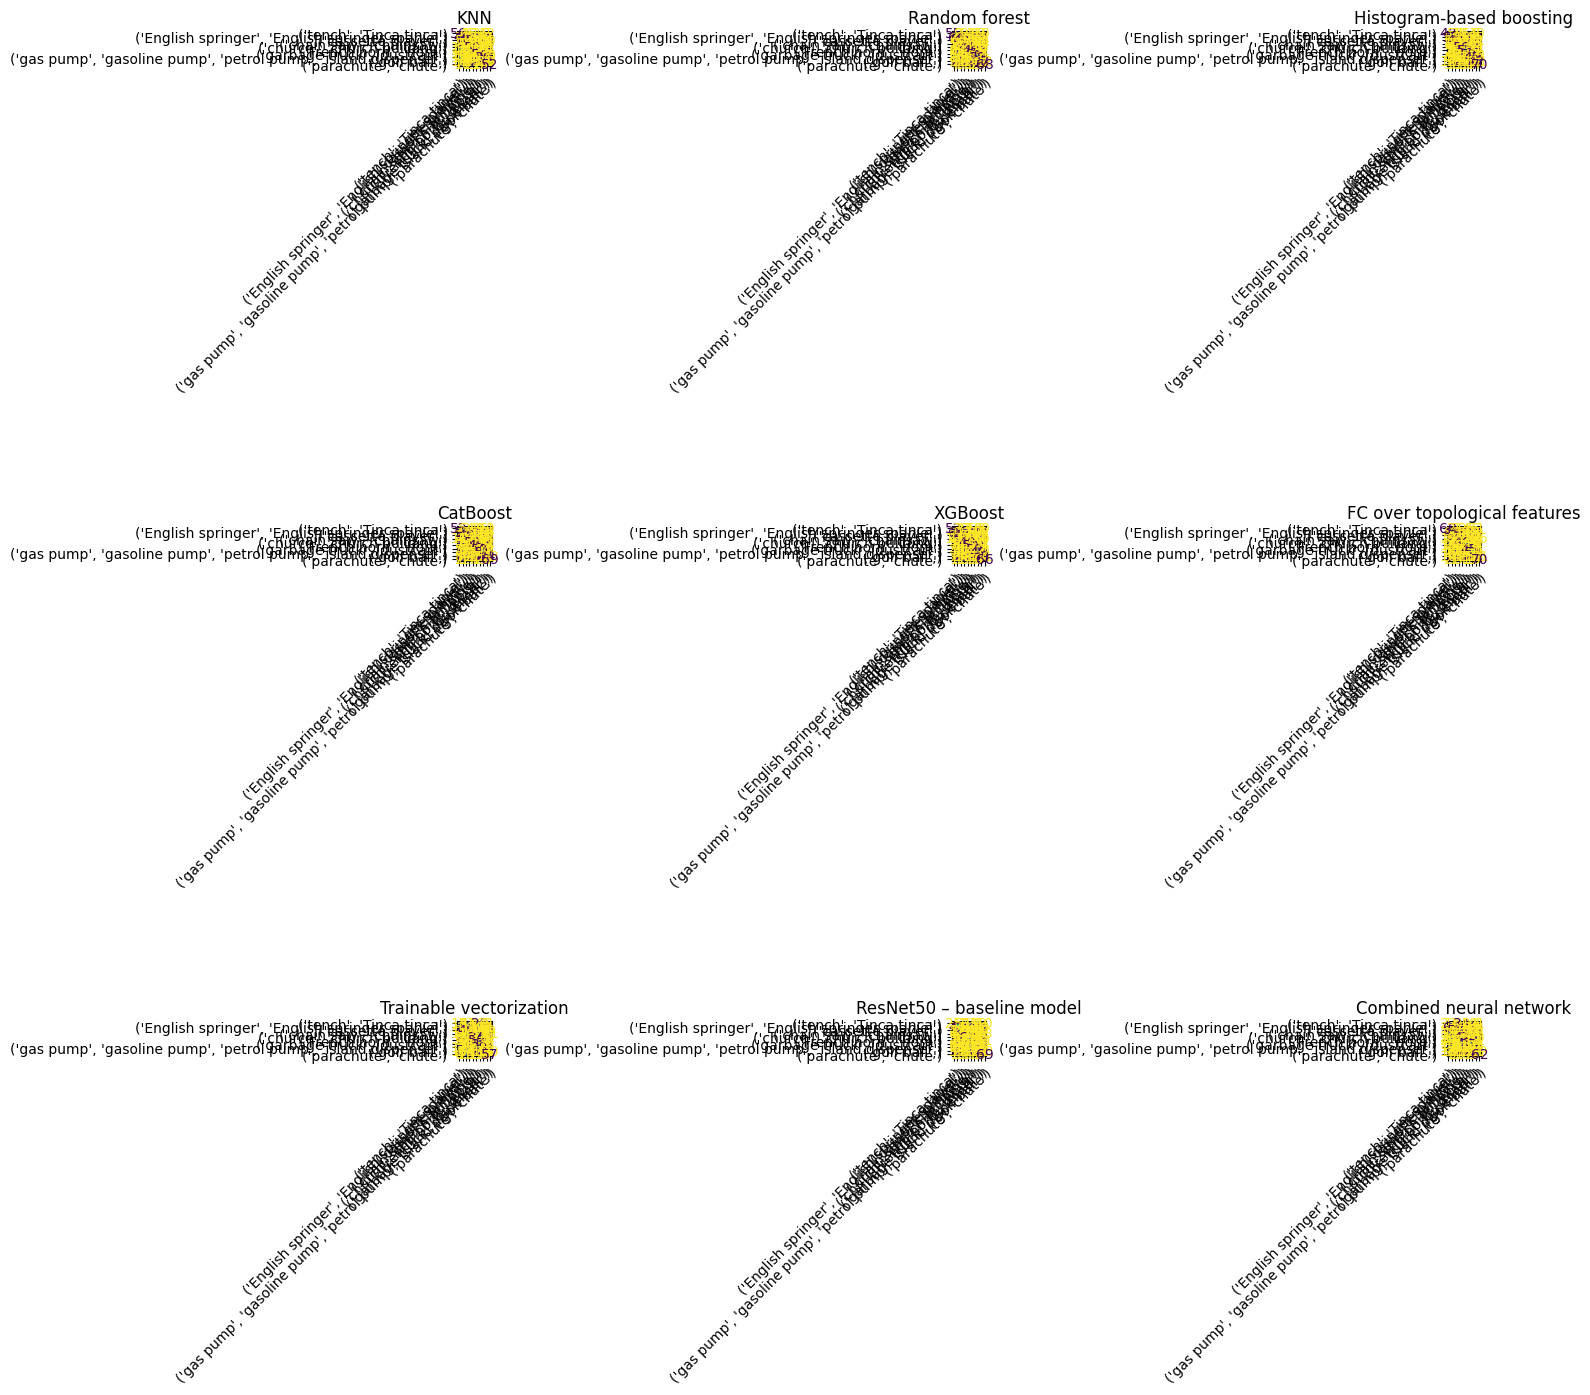

In [20]:
import cvtda.classification

cvtda.classification.classify(
    train_images, train_features, train_labels, train_diagrams,
    test_images, test_features, test_labels, test_diagrams,
    label_names = train.classes, dump_name = "predictions", only_get_from_dump = False,
    catboost_iterations = 100, nn_epochs = 4, nn_batch_size = 64, nn_learning_rate = 1e-4, 
)

Processing mnist


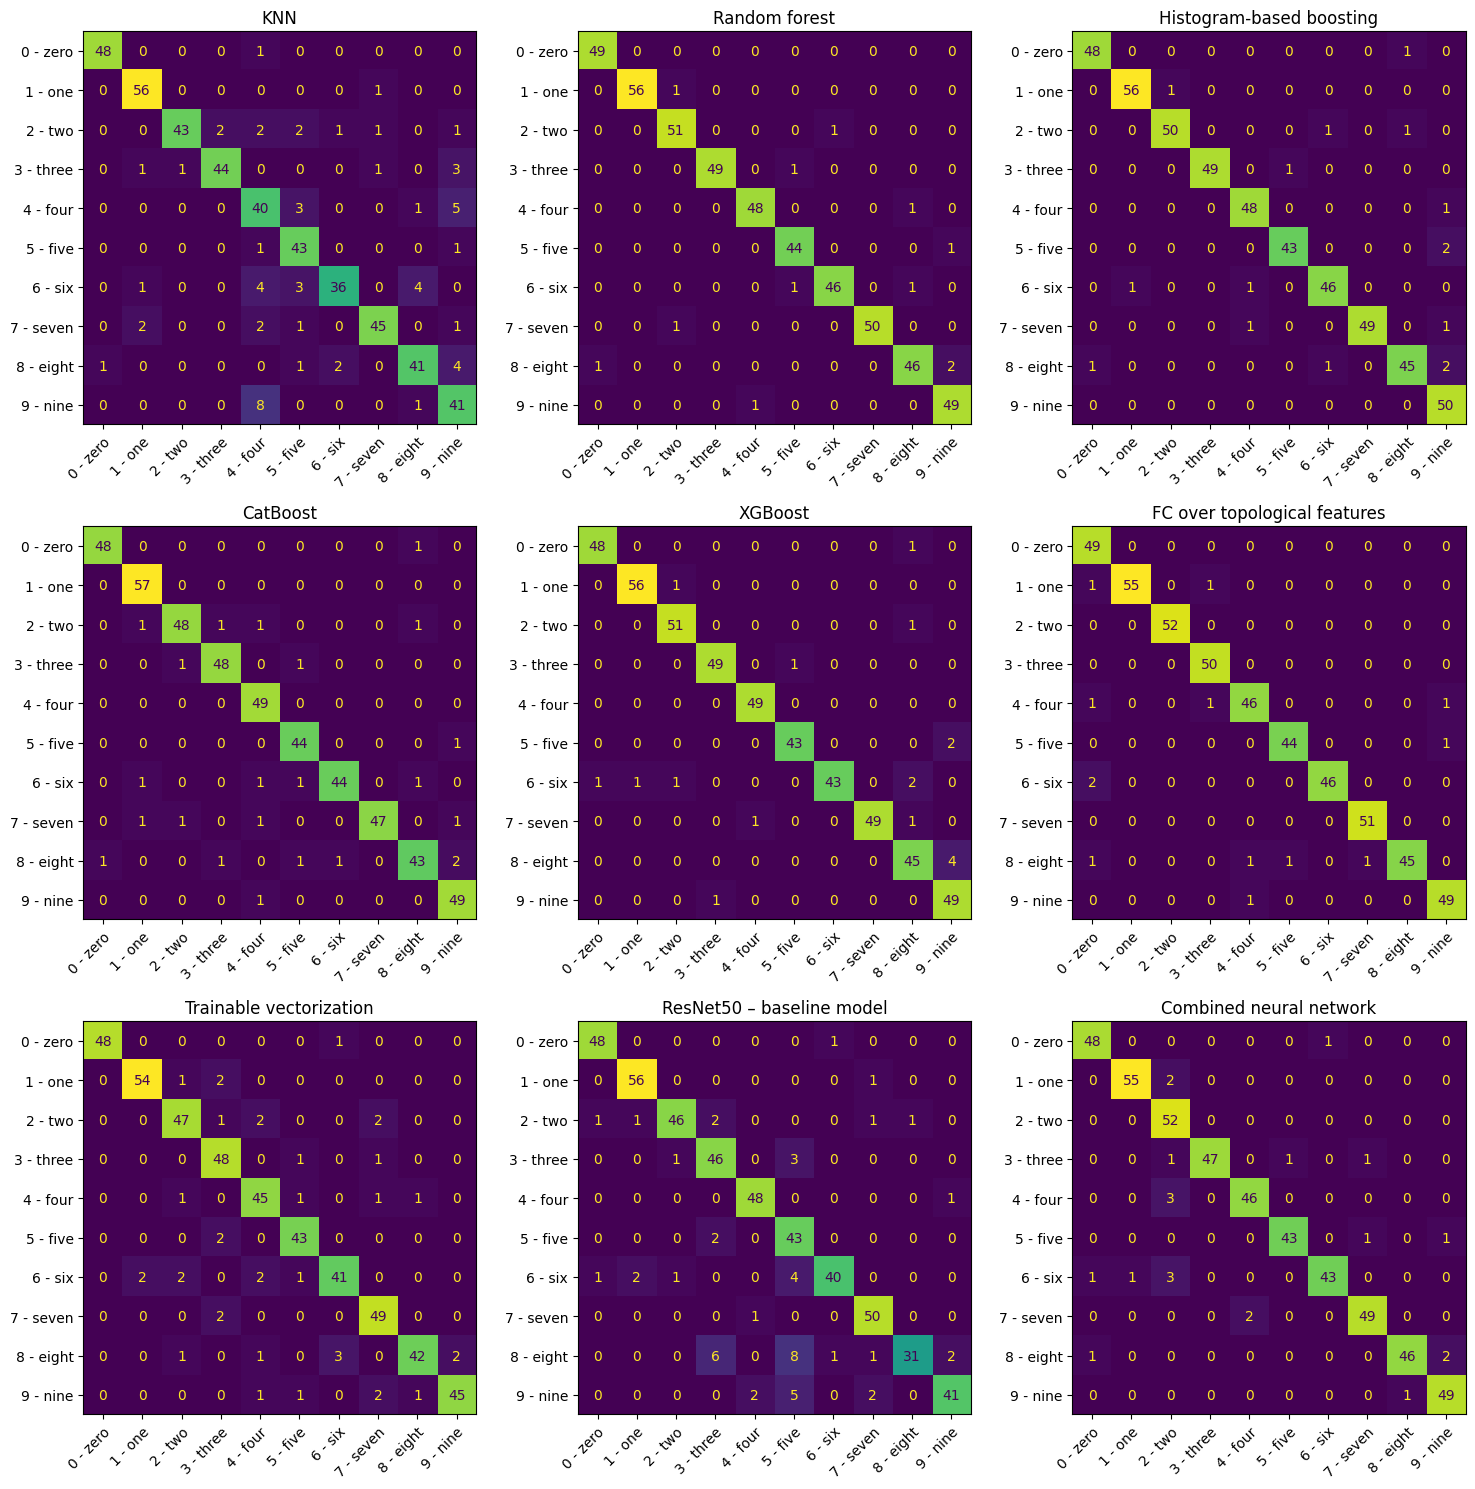

In [3]:
FRACTION = {
    'mnist': 0.05
}


features_extraction_params = dict(
    reduced = True,
    with_inverted = False,
    num_radial_filtrations = 2,
    binarizer_thresholds = [0.5],
    height_filtration_directions = [(-1, -1), (1, -1), (-1, 1), (1, 1)]
)

classification_params = dict(
    catboost_iterations = 100, nn_epochs = 4, nn_batch_size = 64, nn_learning_rate = 1e-4
)

import numpy
import torchvision
import cvtda.utils
import cvtda.topology
import cvtda.logging
import cvtda.classification
import sklearn.model_selection

def classification(name, train, test):
    print(f"Processing {name}")
    folder = f"{name}/results"

    train_images = numpy.array([ numpy.array(item[0]) / 255 for item in train ])
    train_labels = numpy.array([ item[1] for item in train ])

    test_images = numpy.array([ numpy.array(item[0]) / 255 for item in test ])
    test_labels = numpy.array([ item[1] for item in test ])

    idxs, _ = sklearn.model_selection.train_test_split(
        numpy.arange(len(train_labels)),
        stratify = train_labels,
        train_size = FRACTION[name],
        random_state = 42
    )
    train_images = train_images[idxs]
    train_labels = train_labels[idxs]

    idxs, _ = sklearn.model_selection.train_test_split(
        numpy.arange(len(test_labels)),
        stratify = test_labels,
        train_size = FRACTION[name],
        random_state = 42
    )
    test_images = test_images[idxs]
    test_labels = test_labels[idxs]

    if len(train_images.shape) == 4:
        train_images = cvtda.utils.rgb2gray(train_images[idxs])
        test_images = cvtda.utils.rgb2gray(test_images[idxs])

    features_extractor = cvtda.topology.FeatureExtractor(
        only_get_from_dump = False, return_diagrams = False, **features_extraction_params
    )
    train_features = features_extractor.fit_transform(train_images, f"{folder}/train")
    test_features = features_extractor.transform(test_images, f"{folder}/test")
    
    diagrams_extractor = cvtda.topology.FeatureExtractor(
        only_get_from_dump = True, return_diagrams = True, **features_extraction_params
    )
    train_diagrams = diagrams_extractor.fit_transform(train_images, f"{folder}/train")
    test_diagrams = diagrams_extractor.transform(test_images, f"{folder}/test")

    cvtda.classification.classify(
        train_images, train_features, train_labels, train_diagrams,
        test_images, test_features, test_labels, test_diagrams,
        dump_name = f"{folder}/predictions", only_get_from_dump = False,
        label_names = train.classes, **classification_params
    )

with cvtda.logging.DevNullLogger():
    classification(
        'mnist',
        torchvision.datasets.MNIST('mnist', train = True, download = True),
        torchvision.datasets.MNIST('mnist', train = False, download = True)
    )
